# Session 8 — Model Replacement Demo

## Pre-trained Models FTW: from a zero-shot NLI baseline to stronger bot classifiers

This notebook is a **lecture + seminar demonstration notebook** for Session 8 of *Building ML Solutions*.

The key production invariant is simple:

> We may change the model inside the service, but the external `/predict` contract must stay unchanged.

The key scoring field is `is_bot_probability` in `[0, 1]`. The full `/predict` response may also include the IDs required by the service template, and those fields must stay unchanged. It should not matter whether the probability comes from zero-shot NLI, CatBoost, TF-IDF, embeddings, LoRA, or an ensemble.

## What we will show

We will use the competition-style files `train.json` and `ytrain.csv`:

- `train.json` contains dialogues. The top-level keys are `dialog_id`. Each dialogue is a list of messages.
- Each message has `text`, `message` number, and `participant_index` (`0` or `1`).
- `ytrain.csv` contains labels for each `(dialog_id, participant_index)` pair.
- `is_bot = 1` means this participant is a bot; `is_bot = 0` means this participant is human.

Routes covered in this notebook:

| Route | Who should try it | What it gives |
|---|---|---|
| A. CatBoost manual features | everyone | fast strong baseline, low latency |
| B. Embeddings + CatBoost | most teams | pre-trained text representations + tabular features |
| C. TF-IDF + LogisticRegression | low compute teams | simple and reliable text baseline |
| D. Zero-shot NLI | no-training route | human/bot hypothesis comparison and latency check |
| E. LoRA sequence classifier | advanced / GPU | supervised transformer adaptation |
| F. Ensemble | stronger teams | blend several imperfect signals |

We will also include a short **CV and multimodal** for a 5–10 minute lecture demo

## How to run this notebook

Recommended lecture mode:

1. Run setup and data loading.
2. Run CatBoost manual features.
3. Run embedding-style route with the default lightweight fallback.
4. Run TF-IDF baseline.
5. Show zero-shot NLI and LoRA cells as optional / advanced cells.
6. Finish with the service-shaped wrapper and the comparison table.

The notebook is designed to run end-to-end without downloading large models. Heavy Hugging Face demos are behind flags.

In [ ]:
# ============================================================
# 0. Runtime settings
# ============================================================

RUN_OPTIONAL_INSTALLS = True

RUN_HF_EMBEDDINGS = True       # True -> use SentenceTransformer E5/SBERT if available
RUN_ZERO_SHOT_NLI = True       # True -> load facebook/bart-large-mnli or multilingual NLI
RUN_LORA_SETUP = True          # True -> instantiate a small LoRA sequence classifier
RUN_CV_DEMO = True             # True -> optional image classification demo
RUN_MULTIMODAL_DEMO = True     # True -> optional CLIP text-image matching demo

RANDOM_STATE = 42
VALID_SIZE = 0.25

print('Runtime flags are set. Heavy demos are disabled by default.')

Runtime flags are set. Heavy demos are disabled by default.


In [ ]:
if RUN_OPTIONAL_INSTALLS:
    import sys, subprocess
    packages = [
        'catboost',
        'sentence-transformers',
        'transformers',
        'peft',
        'accelerate',
        'pillow',
    ]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
    print('Optional packages installed.')
else:
    print('Skipping optional installs. Set RUN_OPTIONAL_INSTALLS=True in Colab if needed.')

Optional packages installed.


In [ ]:
# ============================================================
# 1. Imports and shared helpers
# ============================================================

import json
import os
import re
import time
import warnings
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import BaseEstimator
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_STATE)


def package_available(package_name: str) -> bool:
    import importlib.util
    return importlib.util.find_spec(package_name) is not None


def find_data_file(filename: str) -> Path | None:
    """Find data in common notebook locations."""
    candidates = [
        Path.cwd() / filename,
        Path('/mnt/data') / filename,
        Path('/content') / filename,
        Path('/content/drive/MyDrive') / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    return None


def safe_div(a: float, b: float) -> float:
    return float(a) / float(b) if b else 0.0


def clip_probability(x: float) -> float:
    return float(np.clip(x, 0.0, 1.0))

print('Core libraries loaded.')
print('catboost available:', package_available('catboost'))
print('sentence_transformers available:', package_available('sentence_transformers'))
print('transformers available:', package_available('transformers'))

Core libraries loaded.
catboost available: True
sentence_transformers available: True
transformers available: True


# Part 1 — Load and inspect the competition data

The platform does not ask us to classify a whole dialogue. It asks for a probability for **one participant**.

So we must train and predict at the level of:

```text
(dialog_id, participant_index) -> is_bot_probability
```

This is also where leakage can happen. If we split by individual rows, the same dialogue can appear in both train and validation. We will split by `dialog_id` instead.

In [ ]:
# ============================================================
# 2. Load train.json and ytrain.csv
# ============================================================

train_path = find_data_file('train.json')
ytrain_path = find_data_file('ytrain.csv')

if train_path is None or ytrain_path is None:
    print('train.json or ytrain.csv not found. Creating a tiny fallback sample for code demonstration.')
    fallback_dialogs = {
        'd1': [
            {'message': 0, 'text': 'Hi, how are you?', 'participant_index': '0'},
            {'message': 1, 'text': 'Hello! How can I assist you today?', 'participant_index': '1'},
        ],
        'd2': [
            {'message': 0, 'text': 'Привет, как дела?', 'participant_index': '0'},
            {'message': 1, 'text': 'норм, кофе допиваю', 'participant_index': '1'},
        ],
        'd3': [
            {'message': 0, 'text': 'Tell me about Docker Compose', 'participant_index': '0'},
            {'message': 1, 'text': 'Docker Compose is a tool for multi-container apps.', 'participant_index': '1'},
        ],
        'd4': [
            {'message': 0, 'text': 'ахах, ну ты даешь', 'participant_index': '0'},
            {'message': 1, 'text': 'да ладно, просто смешно', 'participant_index': '1'},
        ],
        'd5': [
            {'message': 0, 'text': 'Are you a bot?', 'participant_index': '0'},
            {'message': 1, 'text': 'I am an AI assistant created to help users.', 'participant_index': '1'},
        ],
        'd6': [
            {'message': 0, 'text': 'го за шоколадкой', 'participant_index': '0'},
            {'message': 1, 'text': 'ахах, давай', 'participant_index': '1'},
        ],
    }
    fallback_y = pd.DataFrame([
        {'dialog_id': 'd1', 'participant_index': 0, 'is_bot': 0},
        {'dialog_id': 'd1', 'participant_index': 1, 'is_bot': 1},
        {'dialog_id': 'd2', 'participant_index': 0, 'is_bot': 0},
        {'dialog_id': 'd2', 'participant_index': 1, 'is_bot': 0},
        {'dialog_id': 'd3', 'participant_index': 0, 'is_bot': 0},
        {'dialog_id': 'd3', 'participant_index': 1, 'is_bot': 1},
        {'dialog_id': 'd4', 'participant_index': 0, 'is_bot': 0},
        {'dialog_id': 'd4', 'participant_index': 1, 'is_bot': 0},
        {'dialog_id': 'd5', 'participant_index': 0, 'is_bot': 0},
        {'dialog_id': 'd5', 'participant_index': 1, 'is_bot': 1},
        {'dialog_id': 'd6', 'participant_index': 0, 'is_bot': 0},
        {'dialog_id': 'd6', 'participant_index': 1, 'is_bot': 0},
    ])
    dialogs = fallback_dialogs
    ytrain = fallback_y
else:
    print(f'Using train file:  {train_path}')
    print(f'Using label file:  {ytrain_path}')
    with open(train_path, 'r', encoding='utf-8') as f:
        dialogs = json.load(f)
    ytrain = pd.read_csv(ytrain_path)

# Normalize dtypes.
ytrain['participant_index'] = ytrain['participant_index'].astype(int)
ytrain['is_bot'] = ytrain['is_bot'].astype(int)

print(f'Number of dialogues: {len(dialogs):,}')
print(f'Number of labelled participants: {len(ytrain):,}')
display(ytrain.head())
display(ytrain['is_bot'].value_counts().rename_axis('is_bot').to_frame('count'))

Using train file:  /content/train.json
Using label file:  /content/ytrain.csv
Number of dialogues: 786
Number of labelled participants: 1,572


,dialog_id,participant_index,is_bot
0,dae9e2dae9f840549764f8d9bbbb80f0,0,0
1,159da0d7937c4c1e84a51f0df7e3ade6,0,0
2,1aed86f082234446951360d00979f0d9,0,0
3,ab3dbd121828403ba30d0ed4008fbea4,0,0
4,08ce7e4224cc411ba629f1983eba031f,0,1


,count
is_bot,
0,1033
1,539


In [ ]:
# Show a small safe preview of train.json without printing full raw dialogues.

first_dialog_id = next(iter(dialogs))
preview_messages = pd.DataFrame(dialogs[first_dialog_id]).copy()
preview_messages['text_preview'] = preview_messages['text'].fillna('').astype(str).str.slice(0, 120)
preview_messages = preview_messages[['message', 'participant_index', 'text_preview']]

print('Example dialog_id:', first_dialog_id)
display(preview_messages)

Example dialog_id: dae9e2dae9f840549764f8d9bbbb80f0


,message,participant_index,text_preview
0,0,0,Hello!
1,1,1,Как дела?
2,2,0,Отлично! А твои?
3,3,1,Это круто!
4,4,0,Расскажи теорему


## Build a participant-level table

For each dialogue we create two rows: participant `0` and participant `1`.

Useful columns:

- `speaker_text`: only messages written by the participant we classify;
- `other_text`: messages from the other participant;
- `dialogue_text`: full dialogue with speaker tags;
- `is_bot`: label from `ytrain.csv`.

For the production service, be careful with history. In a live `/predict` call, you should only use messages that have already arrived for that `dialog_id`.

In [ ]:
# ============================================================
# 3. Convert raw dialogues into participant-level examples
# ============================================================

def make_participant_table(dialogs: dict[str, list[dict[str, Any]]], labels: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for dialog_id, messages in dialogs.items():
        messages_sorted = sorted(messages, key=lambda x: int(x.get('message', 0)))
        participant_ids = sorted({int(m.get('participant_index')) for m in messages_sorted})
        # The platform normally uses 0 and 1, but this keeps the loader robust.
        for participant_index in participant_ids:
            speaker_messages: list[str] = []
            other_messages: list[str] = []
            dialogue_lines: list[str] = []
            for m in messages_sorted:
                text = str(m.get('text') or '')
                pi = int(m.get('participant_index'))
                dialogue_lines.append(f'P{pi}: {text}')
                if pi == participant_index:
                    speaker_messages.append(text)
                else:
                    other_messages.append(text)

            rows.append({
                'dialog_id': dialog_id,
                'participant_index': participant_index,
                'speaker_text': '\n'.join(speaker_messages),
                'other_text': '\n'.join(other_messages),
                'dialogue_text': '\n'.join(dialogue_lines),
                'speaker_messages': speaker_messages,
                'n_messages_total': len(messages_sorted),
                'n_messages_speaker': len(speaker_messages),
                'n_messages_other': len(other_messages),
            })

    df = pd.DataFrame(rows)
    df = df.merge(labels, on=['dialog_id', 'participant_index'], how='left')
    missing = df['is_bot'].isna().sum()
    if missing:
        raise ValueError(f'{missing} participant rows have no label in ytrain.csv')
    df['is_bot'] = df['is_bot'].astype(int)
    return df

examples = make_participant_table(dialogs, ytrain)
print(examples.shape)
display(examples.head(6)[['dialog_id', 'participant_index', 'n_messages_speaker', 'is_bot']])

(1572, 10)


,dialog_id,participant_index,n_messages_speaker,is_bot
0,dae9e2dae9f840549764f8d9bbbb80f0,0,3,0
1,dae9e2dae9f840549764f8d9bbbb80f0,1,2,0
2,159da0d7937c4c1e84a51f0df7e3ade6,0,7,0
3,159da0d7937c4c1e84a51f0df7e3ade6,1,7,1
4,1aed86f082234446951360d00979f0d9,0,2,0
5,1aed86f082234446951360d00979f0d9,1,2,1


In [ ]:
# Label balance and text length overview.

overview = examples.assign(
    speaker_chars=examples['speaker_text'].str.len(),
    speaker_words=examples['speaker_text'].str.split().map(len),
)

summary = overview.groupby('is_bot')[['speaker_chars', 'speaker_words', 'n_messages_speaker']].agg(['count', 'mean', 'median']).round(2)
display(summary)

speaker_chars                speaker_words                \
               count    mean median         count   mean median   
is_bot                                                            
0               1033  109.34   42.0          1033  16.04    7.0   
1                539  172.50   75.0           539  27.68   14.0   

       n_messages_speaker               
                    count  mean median  
is_bot                                  
0                    1033  3.76    3.0  
1                     539  4.54    4.0

## Train/validation split and evaluation helpers

We split by `dialog_id`, not by rows. This prevents the same conversation from appearing in both train and validation.

Metrics:

- `ROC-AUC`: ranking quality;
- `F1`: quality at threshold `0.5`;
- `log_loss` and `brier`: probability quality;
- `p50_ms` and `p95_ms`: approximate inference latency on validation examples.

In [ ]:
# ============================================================
# 4. Split by dialog_id and define metric helpers
# ============================================================

unique_dialog_ids = examples['dialog_id'].unique()
train_dialog_ids, valid_dialog_ids = train_test_split(
    unique_dialog_ids,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE,
)

train_mask = examples['dialog_id'].isin(train_dialog_ids)
valid_mask = ~train_mask

y_train = examples.loc[train_mask, 'is_bot'].astype(int).reset_index(drop=True)
y_valid = examples.loc[valid_mask, 'is_bot'].astype(int).reset_index(drop=True)

print(f'Train participants: {train_mask.sum():,}')
print(f'Valid participants: {valid_mask.sum():,}')
print('Validation label balance:')
display(y_valid.value_counts().rename_axis('is_bot').to_frame('count'))

valid_predictions: dict[str, np.ndarray] = {}
metrics_rows: list[dict[str, float | str]] = []


def evaluate_predictions(name: str, y_true: pd.Series | np.ndarray, proba: np.ndarray, latency_ms: np.ndarray | None = None) -> dict[str, float | str]:
    y_arr = np.asarray(y_true).astype(int)
    p = np.clip(np.asarray(proba, dtype=float), 1e-6, 1 - 1e-6)
    pred = (p >= 0.5).astype(int)

    def safe_metric(fn, default=np.nan):
        try:
            return float(fn())
        except Exception:
            return float(default)

    row: dict[str, float | str] = {
        'model': name,
        'roc_auc': safe_metric(lambda: roc_auc_score(y_arr, p)),
        'accuracy@0.5': safe_metric(lambda: accuracy_score(y_arr, pred)),
        'f1@0.5': safe_metric(lambda: f1_score(y_arr, pred)),
        'log_loss': safe_metric(lambda: log_loss(y_arr, p)),
        'brier': safe_metric(lambda: brier_score_loss(y_arr, p)),
    }
    if latency_ms is not None and len(latency_ms):
        row['p50_ms'] = float(np.percentile(latency_ms, 50))
        row['p95_ms'] = float(np.percentile(latency_ms, 95))
    else:
        row['p50_ms'] = np.nan
        row['p95_ms'] = np.nan
    return row


def add_result(name: str, proba: np.ndarray, latency_ms: np.ndarray | None = None):
    valid_predictions[name] = np.asarray(proba, dtype=float)
    row = evaluate_predictions(name, y_valid, proba, latency_ms)
    metrics_rows.append(row)
    display(pd.DataFrame([row]).round(4))


def measure_predict_latency(predict_fn, inputs: list[Any], n: int = 100) -> np.ndarray:
    """Measure approximate per-example latency on a small sample.

    We run one warm-up prediction first so one-time model setup does not dominate p95.
    """
    if inputs:
        _ = predict_fn(inputs[0])

    latencies = []
    for x in inputs[:n]:
        start = time.perf_counter()
        _ = predict_fn(x)
        latencies.append((time.perf_counter() - start) * 1000)
    return np.asarray(latencies)

# Shared text inputs for text-based routes.
X_text_train = examples.loc[train_mask, 'speaker_text'].reset_index(drop=True)
X_text_valid = examples.loc[valid_mask, 'speaker_text'].reset_index(drop=True)


Train participants: 1,178
Valid participants: 394
Validation label balance:


,count
is_bot,
0,262
1,132


# Part 2 — Route A: CatBoost with manual features

This is the route everyone should try.

It is not a pre-trained model, but it is a strong production baseline:

- fast inference;
- simple deployment;
- returns probabilities that are easy to inspect and calibrate;
- works well with small and noisy datasets;
- easy to combine with embeddings later.

Manual features also help us understand what the data contains before we use heavier models.

In [ ]:
# ============================================================
# Route A. Manual feature engineering
# ============================================================

BOT_MARKERS = [
    'as an ai', 'ai assistant', 'language model', 'chatgpt', 'openai', 'gpt',
    'virtual assistant', 'how can i assist', 'i can help', 'i cannot', "i can't",
    'i do not have', "i don't have", 'i am a bot',
    'я бот', 'я чат-бот', 'чат-бот', 'виртуальный помощник', 'искусственный интеллект',
    'как могу помочь', 'чем могу помочь', 'не могу', 'не имею', 'мои возможности', 'обращаться',
]

HUMAN_STYLE_MARKERS = [
    'лол', 'ахах', 'хаха', 'бро', 'чел', 'ну', 'ок', 'спс', 'не бот', 'я человек',
]


def text_stats(prefix: str, text: str) -> dict[str, float]:
    text = '' if text is None else str(text)
    lower = text.lower()
    words = re.findall(r'\w+', lower, flags=re.UNICODE)
    chars = len(text)
    unique_words = len(set(words))
    cyrillic_chars = sum(('а' <= ch.lower() <= 'я') or ch.lower() == 'ё' for ch in text)
    latin_chars = sum('a' <= ch.lower() <= 'z' for ch in text)

    return {
        f'{prefix}_chars': chars,
        f'{prefix}_words': len(words),
        f'{prefix}_unique_words': unique_words,
        f'{prefix}_type_token_ratio': safe_div(unique_words, len(words)),
        f'{prefix}_avg_word_len': safe_div(sum(map(len, words)), len(words)),
        f'{prefix}_questions': text.count('?'),
        f'{prefix}_exclamations': text.count('!'),
        f'{prefix}_newlines': text.count('\n'),
        f'{prefix}_digits': sum(ch.isdigit() for ch in text),
        f'{prefix}_uppercase_ratio': safe_div(sum(ch.isupper() for ch in text), chars),
        f'{prefix}_cyrillic_ratio': safe_div(cyrillic_chars, chars),
        f'{prefix}_latin_ratio': safe_div(latin_chars, chars),
        f'{prefix}_url_count': lower.count('http://') + lower.count('https://'),
        f'{prefix}_empty_or_space': int(len(text.strip()) == 0),
        f'{prefix}_bot_marker_count': sum(lower.count(marker) for marker in BOT_MARKERS),
        f'{prefix}_human_marker_count': sum(lower.count(marker) for marker in HUMAN_STYLE_MARKERS),
    }


def repetition_features(messages: list[str]) -> dict[str, float]:
    clean = [str(m).strip().lower() for m in messages if str(m).strip()]
    if not clean:
        return {'repeat_ratio': 0.0, 'max_repeat_count': 0.0, 'avg_msg_chars': 0.0}
    counts = pd.Series(clean).value_counts()
    return {
        'repeat_ratio': safe_div(float((counts > 1).sum()), float(len(counts))),
        'max_repeat_count': float(counts.iloc[0]),
        'avg_msg_chars': float(np.mean([len(m) for m in clean])),
    }


def build_manual_features(df: pd.DataFrame) -> pd.DataFrame:
    feature_rows = []
    for _, row in df.iterrows():
        features: dict[str, float] = {
            'n_messages_total': float(row['n_messages_total']),
            'n_messages_speaker': float(row['n_messages_speaker']),
            'n_messages_other': float(row['n_messages_other']),
            'speaker_share': safe_div(row['n_messages_speaker'], row['n_messages_total']),
        }
        features.update(text_stats('speaker', row['speaker_text']))
        features.update(text_stats('dialogue', row['dialogue_text']))
        rep = repetition_features(row['speaker_messages'])
        features.update({f'speaker_{k}': v for k, v in rep.items()})
        feature_rows.append(features)

    return pd.DataFrame(feature_rows).fillna(0.0)

manual_features = build_manual_features(examples)
manual_train = manual_features.loc[train_mask].reset_index(drop=True)
manual_valid = manual_features.loc[valid_mask].reset_index(drop=True)

print('Manual feature matrix:', manual_features.shape)
display(manual_features.head())

Manual feature matrix: (1572, 39)


,n_messages_total,n_messages_speaker,n_messages_other,speaker_share,speaker_chars,speaker_words,speaker_unique_words,speaker_type_token_ratio,speaker_avg_word_len,speaker_questions,...,dialogue_uppercase_ratio,dialogue_cyrillic_ratio,dialogue_latin_ratio,dialogue_url_count,dialogue_empty_or_space,dialogue_bot_marker_count,dialogue_human_marker_count,speaker_repeat_ratio,speaker_max_repeat_count,speaker_avg_msg_chars
0,5.0,3.0,2.0,0.6,40,6,6,1.000000,5.333333,1,...,0.135802,0.518519,0.123457,0,0,0,0,0.0,1.0,12.666667
1,5.0,2.0,3.0,0.4,20,4,4,1.000000,3.750000,1,...,0.135802,0.518519,0.123457,0,0,0,0,0.0,1.0,9.500000
2,14.0,7.0,7.0,0.5,65,7,7,1.000000,8.428571,0,...,0.037958,0.748691,0.018325,0,0,1,5,0.0,1.0,8.428571
3,14.0,7.0,7.0,0.5,642,106,61,0.575472,4.839623,1,...,0.037958,0.748691,0.018325,0,0,1,5,0.0,1.0,90.857143
4,4.0,2.0,2.0,0.5,14,3,3,1.000000,3.666667,1,...,0.140351,0.508772,0.070175,0,0,0,0,0.0,1.0,6.500000


In [ ]:
# ============================================================
# Route A. Fit CatBoost manual-feature baseline
# ============================================================

def make_tree_model() -> tuple[str, BaseEstimator]:
    """Use CatBoost when available. Fallback keeps the notebook runnable."""
    if package_available('catboost'):
        from catboost import CatBoostClassifier
        model = CatBoostClassifier(
            iterations=80,
            depth=4,
            learning_rate=0.08,
            loss_function='Logloss',
            eval_metric='AUC',
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )
        return 'CatBoost manual features', model

    model = HistGradientBoostingClassifier(
        max_iter=120,
        learning_rate=0.06,
        random_state=RANDOM_STATE,
    )
    return 'sklearn HGB manual features', model

manual_model_name, manual_model = make_tree_model()
start = time.perf_counter()

try:
    manual_model.fit(manual_train, y_train, eval_set=(manual_valid, y_valid), use_best_model=True)
except TypeError:
    manual_model.fit(manual_train, y_train)

fit_seconds = time.perf_counter() - start
manual_valid_proba = manual_model.predict_proba(manual_valid)[:, 1]

lat_manual = measure_predict_latency(
    lambda row: manual_model.predict_proba(np.asarray(row).reshape(1, -1))[:, 1][0],
    [manual_valid.iloc[i].to_numpy() for i in range(len(manual_valid))],
    n=min(100, len(manual_valid)),
)

print(f'Fitted {manual_model_name} in {fit_seconds:.2f} seconds')
add_result(manual_model_name, manual_valid_proba, lat_manual)

Fitted CatBoost manual features in 0.30 seconds


,model,roc_auc,accuracy@0.5,f1@0.5,log_loss,brier,p50_ms,p95_ms
0,CatBoost manual features,0.7719,0.7716,0.5833,0.5239,0.171,0.3387,0.3996


# Part 3 — Route B: Embeddings + CatBoost

Embeddings are often the most practical pre-trained route.

Production advantages:

- easy to cache;
- easy to batch;
- easy to combine with manual features;
- can be searched with FAISS or compared to nearest examples;
- much cheaper than running a large NLI model on every request.

In a full Colab run, set `RUN_HF_EMBEDDINGS=True` and use E5/SBERT. For the default lecture run, we use a lightweight local fallback: TF-IDF → SVD → normalized dense vectors. The shape is similar to an embedding route, but it does not require downloads.

In [ ]:
# ============================================================
# Route B. Embedding-style features
# ============================================================

def make_dense_text_features(train_texts: pd.Series, valid_texts: pd.Series):
    """Return dense normalized vectors and a short description."""
    if RUN_HF_EMBEDDINGS and package_available('sentence_transformers'):
        from sentence_transformers import SentenceTransformer
        model_name = 'intfloat/multilingual-e5-small'
        encoder = SentenceTransformer(model_name)
        train_inputs = ['query: ' + str(x) for x in train_texts]
        valid_inputs = ['query: ' + str(x) for x in valid_texts]
        train_emb = encoder.encode(train_inputs, batch_size=32, normalize_embeddings=True, show_progress_bar=True)
        valid_emb = encoder.encode(valid_inputs, batch_size=32, normalize_embeddings=True, show_progress_bar=True)
        return np.asarray(train_emb), np.asarray(valid_emb), f'HF embeddings: {model_name}'

    vectorizer = TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3, 5),
        min_df=2,
        max_features=8_000,
        lowercase=True,
    )
    train_tfidf = vectorizer.fit_transform(train_texts)
    valid_tfidf = vectorizer.transform(valid_texts)

    max_components = min(train_tfidf.shape[0] - 1, train_tfidf.shape[1] - 1, 32)
    if max_components >= 2:
        svd = TruncatedSVD(n_components=max_components, random_state=RANDOM_STATE)
        train_dense = svd.fit_transform(train_tfidf)
        valid_dense = svd.transform(valid_tfidf)
    else:
        train_dense = train_tfidf.toarray()
        valid_dense = valid_tfidf.toarray()

    train_dense = normalize(train_dense)
    valid_dense = normalize(valid_dense)
    return train_dense, valid_dense, 'local fallback: TF-IDF + SVD dense vectors'

start = time.perf_counter()
emb_train, emb_valid, emb_description = make_dense_text_features(X_text_train, X_text_valid)
print(emb_description)
print('Embedding shapes:', emb_train.shape, emb_valid.shape)
print(f'Feature creation time: {time.perf_counter() - start:.2f} seconds')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

HF embeddings: intfloat/multilingual-e5-small
Embedding shapes: (1178, 384) (394, 384)
Feature creation time: 16.28 seconds


In [ ]:
# Combine manual features and dense text features, then fit CatBoost/fallback.

X_emb_train = np.hstack([manual_train.to_numpy(), emb_train])
X_emb_valid = np.hstack([manual_valid.to_numpy(), emb_valid])

emb_model_name, emb_model = make_tree_model()
emb_model_name = emb_model_name.replace('manual features', 'manual + dense text features')

start = time.perf_counter()
try:
    emb_model.fit(X_emb_train, y_train, eval_set=(X_emb_valid, y_valid), use_best_model=True)
except TypeError:
    emb_model.fit(X_emb_train, y_train)
fit_seconds = time.perf_counter() - start

emb_valid_proba = emb_model.predict_proba(X_emb_valid)[:, 1]

lat_emb = measure_predict_latency(
    lambda row: emb_model.predict_proba(np.asarray(row).reshape(1, -1))[:, 1][0],
    [X_emb_valid[i] for i in range(len(X_emb_valid))],
    n=min(100, len(X_emb_valid)),
)

print(f'Fitted {emb_model_name} in {fit_seconds:.2f} seconds')
add_result(emb_model_name, emb_valid_proba, lat_emb)

Fitted CatBoost manual + dense text features in 7.25 seconds


,model,roc_auc,accuracy@0.5,f1@0.5,log_loss,brier,p50_ms,p95_ms
0,CatBoost manual + dense text features,0.7657,0.7589,0.5622,0.5306,0.174,5.4876,9.7014


# Part 4 — Route C: TF-IDF + LogisticRegression

This is the best low-compute text baseline.

We use character n-grams because the data is multilingual, noisy, and contains slang, typos, emojis, copied prompts, and short messages.

This route is useful when:

- you do not have GPU;
- you need a fast baseline today;
- you want a simple model that can be exported with `joblib` and used inside FastAPI.

In [ ]:
# ============================================================
# Route C. TF-IDF + LogisticRegression baseline
# ============================================================

tfidf_logreg = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3, 5),
        min_df=2,
        max_features=8_000,
        lowercase=True,
    )),
    ('clf', LogisticRegression(
        max_iter=1_000,
        solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])


start = time.perf_counter()
tfidf_logreg.fit(X_text_train, y_train)
fit_seconds = time.perf_counter() - start

tfidf_valid_proba = tfidf_logreg.predict_proba(X_text_valid)[:, 1]
lat_tfidf = measure_predict_latency(
    lambda text: tfidf_logreg.predict_proba([text])[:, 1][0],
    list(X_text_valid),
    n=min(100, len(X_text_valid)),
)

print(f'Fitted TF-IDF + LogisticRegression in {fit_seconds:.2f} seconds')
add_result('TF-IDF char ngrams + LogisticRegression', tfidf_valid_proba, lat_tfidf)

Fitted TF-IDF + LogisticRegression in 1.08 seconds


,model,roc_auc,accuracy@0.5,f1@0.5,log_loss,brier,p50_ms,p95_ms
0,TF-IDF char ngrams + LogisticRegression,0.7989,0.7843,0.6718,0.5337,0.1754,3.2189,8.2166


# Part 5 — Route D: Zero-shot NLI baseline

In this seminar version, the first baseline is **zero-shot NLI**:

```text
Premise:      speaker history or dialogue context
Hypotheses:   "This speaker is human."
              "This speaker is a bot."
```

Important details:

- Do not treat “not human” as automatically “bot”. Compare both explicit hypotheses.
- Close scores mean uncertainty.
- NLI scores are not calibrated production probabilities by default.
- Zero-shot is useful as a no-training reference, but it can be slow and sensitive to wording.

This cell is optional because downloading NLI models can take time.

In [ ]:
# ============================================================
# Route D. Optional zero-shot NLI demo
# ============================================================

NLI_MODEL_NAME = 'facebook/bart-large-mnli'
# For more multilingual data, you may also test:
# NLI_MODEL_NAME = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'

zero_shot_pipe = None

if RUN_ZERO_SHOT_NLI:
    if not package_available('transformers'):
        print('transformers is not installed. Set RUN_OPTIONAL_INSTALLS=True or install it manually.')
    else:
        from transformers import pipeline
        start = time.perf_counter()
        zero_shot_pipe = pipeline('zero-shot-classification', model=NLI_MODEL_NAME)
        print(f'Loaded {NLI_MODEL_NAME} in {time.perf_counter() - start:.2f} seconds')
else:
    print('Zero-shot NLI is skipped by default. Set RUN_ZERO_SHOT_NLI=True to run it.')


def zero_shot_bot_probability(text: str) -> float | None:
    """Return bot probability from NLI hypothesis comparison, or None if model is not loaded."""
    if zero_shot_pipe is None:
        return None

    result = zero_shot_pipe(
        text,
        candidate_labels=['This speaker is human.', 'This speaker is a bot.'],
        hypothesis_template='{}',
        multi_label=True,
    )
    scores = dict(zip(result['labels'], result['scores']))
    human_score = float(scores.get('This speaker is human.', 0.0))
    bot_score = float(scores.get('This speaker is a bot.', 0.0))
    return clip_probability(bot_score / max(human_score + bot_score, 1e-9))


sample_for_nli = examples.loc[valid_mask, ['speaker_text', 'is_bot']].head(3).copy()
sample_for_nli['text_preview'] = sample_for_nli['speaker_text'].str.slice(0, 180)

if zero_shot_pipe is None:
    print('Example rows for the NLI route. Probabilities are not computed because the NLI model is not loaded.')
    display(sample_for_nli[['text_preview', 'is_bot']])
else:
    sample_for_nli['zero_shot_bot_probability'] = [
        zero_shot_bot_probability(t) for t in sample_for_nli['speaker_text']
    ]
    display(sample_for_nli[['text_preview', 'is_bot', 'zero_shot_bot_probability']])


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Loaded facebook/bart-large-mnli in 3.39 seconds


,text_preview,is_bot,zero_shot_bot_probability
4,Привет\nТы бот?,0,0.031692
5,Как дела?\nсын божий. А ты?,1,0.020859
14,do you speak english?\ntell me about your day ...,0,0.004254


# Part 6 — Route E: LoRA sequence classifier

LoRA is an advanced route. It is useful after we have evidence that simpler routes fail in systematic ways.

A typical LoRA plan:

1. Choose a small base model that fits your language and runtime budget.
2. Convert each participant history into one training text.
3. Train binary classifier labels: `human = 0`, `bot = 1`.
4. Train only LoRA adapter weights.
5. Compare against CatBoost, TF-IDF, embeddings, and zero-shot NLI.

Do not make LoRA mandatory for every team. It needs GPU time and careful validation.

In [ ]:
!pip uninstall -y torchao

In [ ]:
# ============================================================
# Route E. Optional LoRA setup skeleton
# ============================================================

LORA_BASE_MODEL = 'cointegrated/rubert-tiny2'  # small Russian-friendly model; change if needed

if RUN_LORA_SETUP:
    missing = [p for p in ['transformers', 'peft', 'torch'] if not package_available(p)]
    if missing:
        print('Missing packages for LoRA:', missing)
        print('Install optional packages first or run this in Colab with GPU.')
    else:
        import torch
        from transformers import AutoModelForSequenceClassification, AutoTokenizer
        from peft import LoraConfig, TaskType, get_peft_model

        LABEL2ID = {'human': 0, 'bot': 1}
        ID2LABEL = {v: k for k, v in LABEL2ID.items()}

        tokenizer = AutoTokenizer.from_pretrained(LORA_BASE_MODEL)
        base_model = AutoModelForSequenceClassification.from_pretrained(
            LORA_BASE_MODEL,
            num_labels=2,
            label2id=LABEL2ID,
            id2label=ID2LABEL,
        )

        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=8,
            lora_alpha=32,
            lora_dropout=0.1,
        )
        lora_model = get_peft_model(base_model, lora_config)
        lora_model.print_trainable_parameters()
else:
    print('LoRA setup is skipped by default.')
    print('Set RUN_LORA_SETUP=True in a GPU Colab runtime to instantiate the adapter model.')

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 30,578 || all params: 29,224,972 || trainable%: 0.1046


# Part 7 — Route F: Ensemble

An ensemble is a simple way to combine different views of the same participant:

- manual behavior features;
- text n-grams;
- dense text features;
- optional NLI or LoRA probabilities.

For the seminar, a weighted average is enough. In homework, teams can tune weights on validation data, but they must avoid overfitting the leaderboard.

In [ ]:
# ============================================================
# Route F. Simple ensemble
# ============================================================

print('Available validation prediction arrays:')
for name, pred in valid_predictions.items():
    print(f'- {name}: shape={pred.shape}')

if valid_predictions:
    stacked = np.vstack([np.clip(p, 0.0, 1.0) for p in valid_predictions.values()])
    ensemble_proba = stacked.mean(axis=0)
    add_result('Simple average ensemble', ensemble_proba)
else:
    print('No predictions available for ensembling yet.')

Available validation prediction arrays:
- CatBoost manual features: shape=(394,)
- CatBoost manual + dense text features: shape=(394,)
- TF-IDF char ngrams + LogisticRegression: shape=(394,)


,model,roc_auc,accuracy@0.5,f1@0.5,log_loss,brier,p50_ms,p95_ms
0,Simple average ensemble,0.8157,0.7944,0.6301,0.5011,0.1618,NaN,NaN


In [ ]:
# Comparison table.

metrics_table = pd.DataFrame(metrics_rows).drop_duplicates(subset=['model'], keep='last')
metrics_table = metrics_table.sort_values(['roc_auc', 'f1@0.5'], ascending=False).reset_index(drop=True)
display(metrics_table.round(4))

,model,roc_auc,accuracy@0.5,f1@0.5,log_loss,brier,p50_ms,p95_ms
0,Simple average ensemble,0.8157,0.7944,0.6301,0.5011,0.1618,NaN,NaN
1,TF-IDF char ngrams + LogisticRegression,0.7989,0.7843,0.6718,0.5337,0.1754,3.2189,8.2166
2,CatBoost manual features,0.7719,0.7716,0.5833,0.5239,0.1710,0.3387,0.3996
3,CatBoost manual + dense text features,0.7657,0.7589,0.5622,0.5306,0.1740,5.4876,9.7014


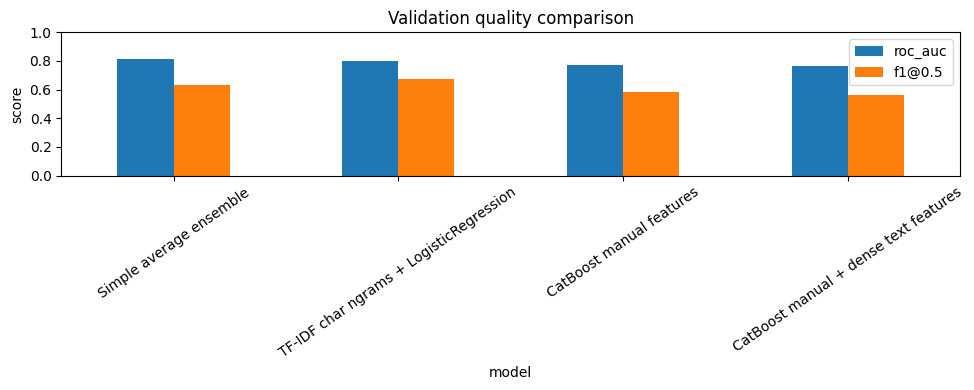

In [ ]:
# Optional quick visualization.

try:
    import matplotlib.pyplot as plt

    plot_df = metrics_table.set_index('model')[['roc_auc', 'f1@0.5']]
    ax = plot_df.plot(kind='bar', figsize=(10, 4), rot=35)
    ax.set_ylim(0, 1)
    ax.set_title('Validation quality comparison')
    ax.set_ylabel('score')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Plot skipped:', repr(e))

# Part 8 — From notebook to `/predict`

A notebook result is still not a service.

The service should expose the same `/predict` contract as before.

The key scoring field is:

```json
{
  "is_bot_probability": 0.42
}
```

If your service template also returns `id`, `message_id`, `dialog_id`, or `participant_index`, keep those fields unchanged.

Implementation rule:

- load the model once at startup;
- do not reload model artifacts inside every request;
- return a float in `[0, 1]`;
- log model name, version, latency, and errors;
- do not put debug details into the platform response.

In [ ]:
# ============================================================
# Service-shaped wrapper
# ============================================================

class DemoBotDetector:
    """Small wrapper that looks like code we can move into src/model_inference.py."""

    def __init__(self, model: Pipeline, model_name: str = 'tfidf-logreg-v1'):
        self.model = model
        self.model_name = model_name

    @staticmethod
    def speaker_history(messages: list[dict[str, Any]], participant_index: int) -> str:
        # In production, only include messages that are already available for this dialog_id.
        texts = []
        for message in sorted(messages, key=lambda x: int(x.get('message', 0))):
            if int(message.get('participant_index')) == int(participant_index):
                texts.append(str(message.get('text') or ''))
        return '\n'.join(texts)

    def predict_proba(self, messages: list[dict[str, Any]], participant_index: int) -> float:
        text = self.speaker_history(messages, participant_index)
        probability = self.model.predict_proba([text])[:, 1][0]
        return clip_probability(probability)


detector = DemoBotDetector(tfidf_logreg)

example_dialog_id = examples.loc[valid_mask, 'dialog_id'].iloc[0]
example_messages = dialogs[example_dialog_id]
example_participant_index = int(examples.loc[valid_mask, 'participant_index'].iloc[0])

start = time.perf_counter()
prob = detector.predict_proba(example_messages, example_participant_index)
latency_ms = (time.perf_counter() - start) * 1000

response = {
    'dialog_id': example_dialog_id,
    'participant_index': example_participant_index,
    'is_bot_probability': prob,
}

print(f'Model: {detector.model_name}')
print(f'Latency: {latency_ms:.3f} ms')
display(response)

Model: tfidf-logreg-v1
Latency: 2.642 ms


{'dialog_id': '1aed86f082234446951360d00979f0d9',
 'participant_index': 0,
 'is_bot_probability': 0.11672906026253313}

In [ ]:
# Export a lightweight artifact that can be copied into the service repository.

import joblib

artifact_dir = Path('artifacts_day08_demo')
artifact_dir.mkdir(exist_ok=True)

joblib.dump(tfidf_logreg, artifact_dir / 'tfidf_logreg_bot_detector.joblib')

metadata = {
    'model_name': 'tfidf-logreg-v1',
    'input': 'speaker history text',
    'output': 'is_bot_probability',
    'notes': 'Demo artifact. Compare against CatBoost, embeddings, zero-shot NLI and LoRA before shipping.',
}
with open(artifact_dir / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print('Saved artifacts:')
for p in artifact_dir.iterdir():
    print('-', p)

Saved artifacts:
- artifacts_day08_demo/metadata.json
- artifacts_day08_demo/tfidf_logreg_bot_detector.joblib


In [ ]:
# Example src/model_inference.py shape. This is a template, not automatically written into your service.

service_code_snippet = r'''
import joblib
import numpy as np
from pathlib import Path

MODEL_PATH = Path("artifacts/tfidf_logreg_bot_detector.joblib")
MODEL_NAME = "tfidf-logreg-v1"

_model = joblib.load(MODEL_PATH)  # load once at process startup


def _speaker_history(messages: list[dict], participant_index: int) -> str:
    texts = []
    for message in sorted(messages, key=lambda x: int(x.get("message", 0))):
        if int(message.get("participant_index")) == int(participant_index):
            texts.append(str(message.get("text") or ""))
    return "\n".join(texts)


def predict_proba(messages: list[dict], participant_index: int) -> float:
    text = _speaker_history(messages, participant_index)
    proba = _model.predict_proba([text])[:, 1][0]
    return float(np.clip(proba, 0.0, 1.0))
'''

print(service_code_snippet)


import joblib
import numpy as np
from pathlib import Path

MODEL_PATH = Path("artifacts/tfidf_logreg_bot_detector.joblib")
MODEL_NAME = "tfidf-logreg-v1"

_model = joblib.load(MODEL_PATH)  # load once at process startup


def _speaker_history(messages: list[dict], participant_index: int) -> str:
    texts = []
    for message in sorted(messages, key=lambda x: int(x.get("message", 0))):
        if int(message.get("participant_index")) == int(participant_index):
            texts.append(str(message.get("text") or ""))
    return "\n".join(texts)


def predict_proba(messages: list[dict], participant_index: int) -> float:
    text = _speaker_history(messages, participant_index)
    proba = _model.predict_proba([text])[:, 1][0]
    return float(np.clip(proba, 0.0, 1.0))



# Part 9 — Optional CV and multimodal

This section is not part of the bot classifier training path.

The purpose is to show the same reuse principle in other modalities:

```text
input -> pre-trained encoder/backbone -> useful representation -> task output
```

For CV and multimodal demos, do not spend time debugging heavy downloads during the lecture. Show the idea, then return to the classifier service.

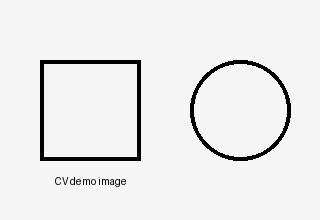

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

,label,score
0,"switch, electric switch, electrical switch",0.851633
1,analog clock,0.008573
2,"loupe, jeweler's loupe",0.008393
3,oil filter,0.007450
4,"rule, ruler",0.006805


In [ ]:
# ============================================================
# Optional CV demo
# ============================================================

try:
    from PIL import Image, ImageDraw

    # A tiny local image so the default cell does not need external files.
    img = Image.new('RGB', (320, 220), color=(245, 245, 245))
    draw = ImageDraw.Draw(img)
    draw.rectangle((40, 60, 140, 160), outline=(0, 0, 0), width=4)
    draw.ellipse((190, 60, 290, 160), outline=(0, 0, 0), width=4)
    draw.text((55, 175), 'CV demo image', fill=(0, 0, 0))
    display(img)
except ImportError:
    img = None
    print('Pillow is not installed, so the local CV image preview is skipped.')

if RUN_CV_DEMO and img is not None:
    if not package_available('transformers'):
        print('transformers is not installed. Install optional packages to run the CV demo.')
    else:
        from transformers import pipeline
        image_classifier = pipeline('image-classification', model='google/vit-base-patch16-224')
        result = image_classifier(img)
        display(pd.DataFrame(result).head())
else:
    print('CV model inference skipped by default.')
    print('Note: ImageNet success does not guarantee production success on medical, satellite, or screenshot data.')


In [ ]:
# ============================================================
# Optional multimodal CLIP-style demo
# ============================================================

if RUN_MULTIMODAL_DEMO and img is not None:
    if not package_available('transformers'):
        print('transformers is not installed. Install optional packages to run the CLIP demo.')
    else:
        import torch
        from transformers import CLIPModel, CLIPProcessor

        model_name = 'openai/clip-vit-base-patch32'
        processor = CLIPProcessor.from_pretrained(model_name)
        clip_model = CLIPModel.from_pretrained(model_name)
        clip_model.eval()

        candidate_texts = ['a rectangle', 'a circle', 'a cat', 'a screenshot']
        inputs = processor(text=candidate_texts, images=img, return_tensors='pt', padding=True)
        with torch.inference_mode():
            outputs = clip_model(**inputs)
            probs = outputs.logits_per_image.softmax(dim=1).cpu().numpy()[0]

        display(pd.DataFrame({'text': candidate_texts, 'probability': probs}).sort_values('probability', ascending=False))
else:
    print('Multimodal CLIP demo skipped by default.')
    print('Note: CLIP maps image and text into comparable vector spaces; FAISS/search uses the same pattern as text embeddings.')


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

,text,probability
0,a rectangle,0.806768
1,a circle,0.173461
3,a screenshot,0.017341
2,a cat,0.002430


# Seminar and homework plan

For practice, students should not all train the same model. They should try different routes and compare honestly.

Minimum recommended submission:

1. Keep `/predict` request and response schema unchanged.
2. Train a **CatBoost manual-features baseline**.
3. Train at least one additional route:
   - TF-IDF + LogisticRegression/SVM;
   - embeddings + CatBoost;
   - zero-shot NLI;
   - LoRA sequence classifier;
   - ensemble.
4. Compare quality, latency, memory, and failure cases.
5. Export the chosen artifact.
6. Integrate it into `src/model_inference.py`.
7. Run the service with Docker/Compose.
8. Smoke-test with `curl` and submit the service URL to the platform.